![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 4. Process Design Kit (PDK) and Layout

In [1]:
import gdsfactory as gf

## 1. Technology

We will work with the **demo UPVfab PDK**. (There are some other open-source PDKs, in other technologies, feel free to search if interested)

In [2]:
from upvfab.sin300.cband import PDK, cells

Let's view the layer distribution of this PDK. In our case, for the passive devices we will only use the **Layer 1**. 

2026-06-06 16:45:26.936 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


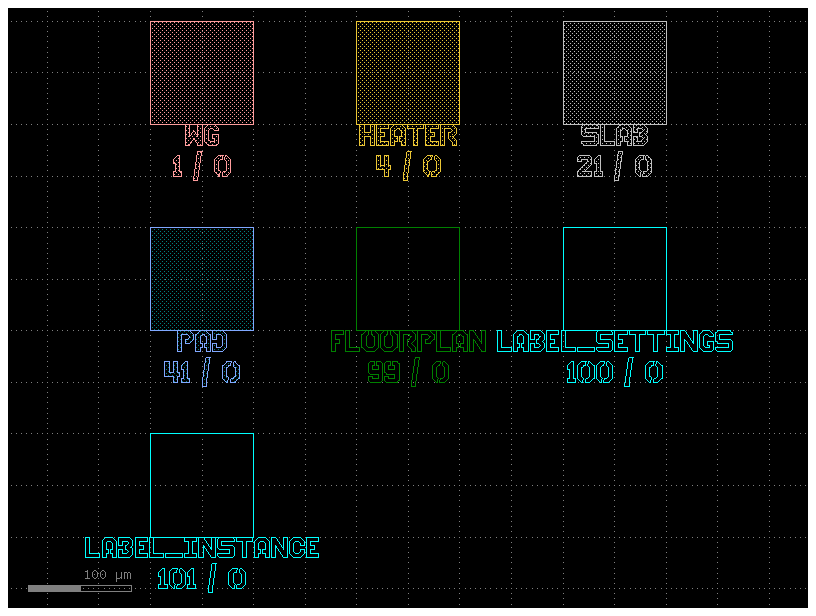

In [3]:
LAYER_VIEWS = PDK.layer_views
c = LAYER_VIEWS.preview_layerset()
c.show()
c.plot()


The new versions of GDS Factory allow to view the Layer Stack also (3D view of the fabrication flow). The following code allows to generate and view the Layer Stack of the generic PDK. Reference: https://www.degruyter.com/document/doi/10.1515/nanoph-2013-0034/html

The layers and the thicknesses have been defined previously on the PDK, so it is possible to view in 3D some of the components in the PDK. 

See the [Reference Manual](https://gdsfactory.github.io/gdsfactory/components.html) and read the list of the available components.

Here are some examples of the 3D views of this photonic components

2026-06-06 16:45:27.192 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


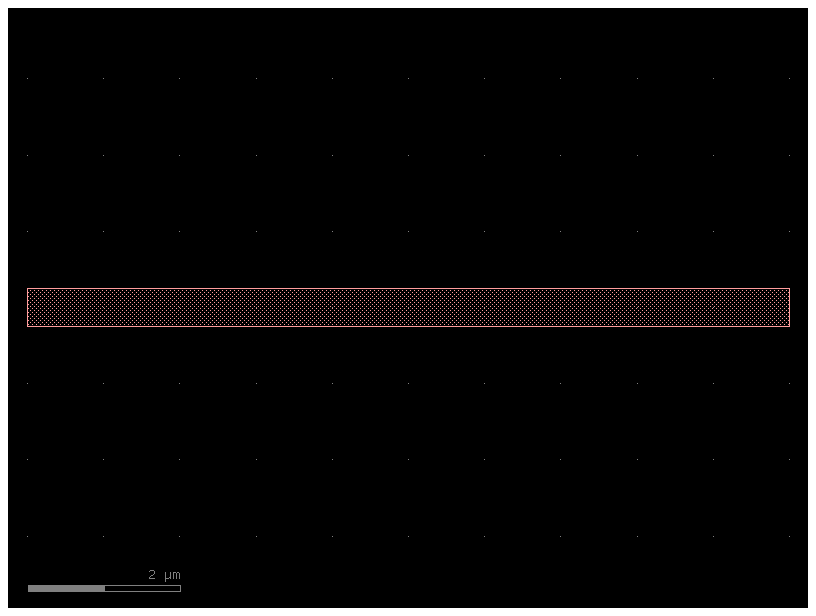

In [4]:
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

c = gf.components.straight(length=10, cross_section=xs)  #Deep 
c.plot() # To view the component on Notebook
c.show() # To view on KLayout
scene = c.to_3d()
scene.show()


2026-06-06 16:45:27.383 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-06 16:45:27.419 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


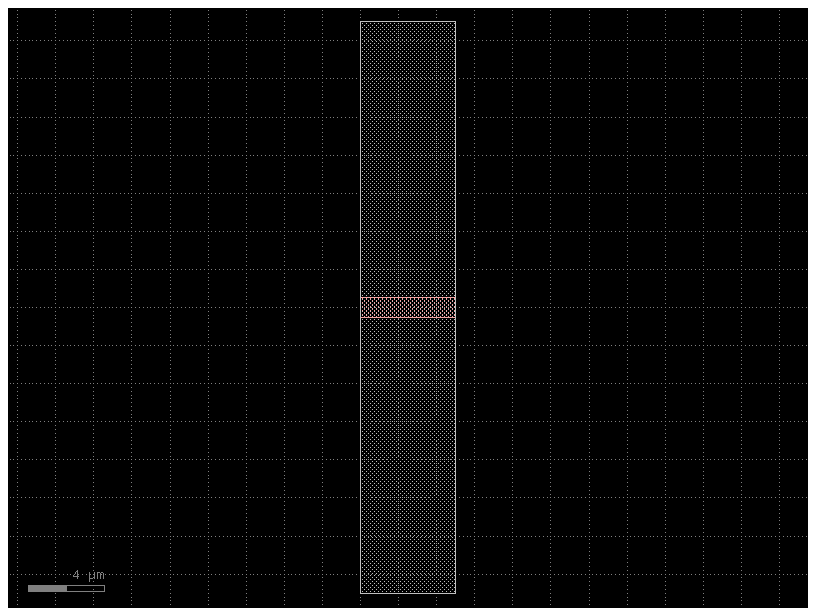

In [5]:
c = gf.components.straight(length=5, cross_section='rib') #Shallow
c.plot()
c.show()

scene = c.to_3d()
c.show()
scene.show()

In [6]:
c = cells.taper_strip_to_ridge(length=10) #Taper
c.show()

scene = c.to_3d()
scene.show()

2026-06-06 16:45:27.565 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


2026-06-06 16:45:27.711 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


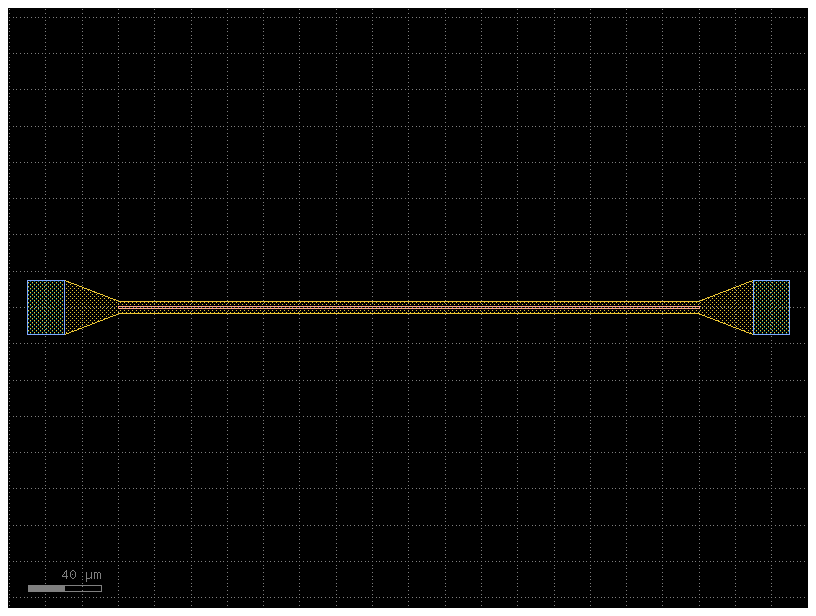

In [7]:
c = cells.straight_heater_metal()

#c.pprint_ports()

c.plot()
c.show()
#c.draw_ports()

scene = c.to_3d()
scene.show()

- Use your design results from Lab2 and Lab3 to create **layout** instances of your designed components: DCs, MMIs, MZIs & Ring Resonators. 

### A. Directional Couplers (DC)

2026-06-06 19:50:41.072 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


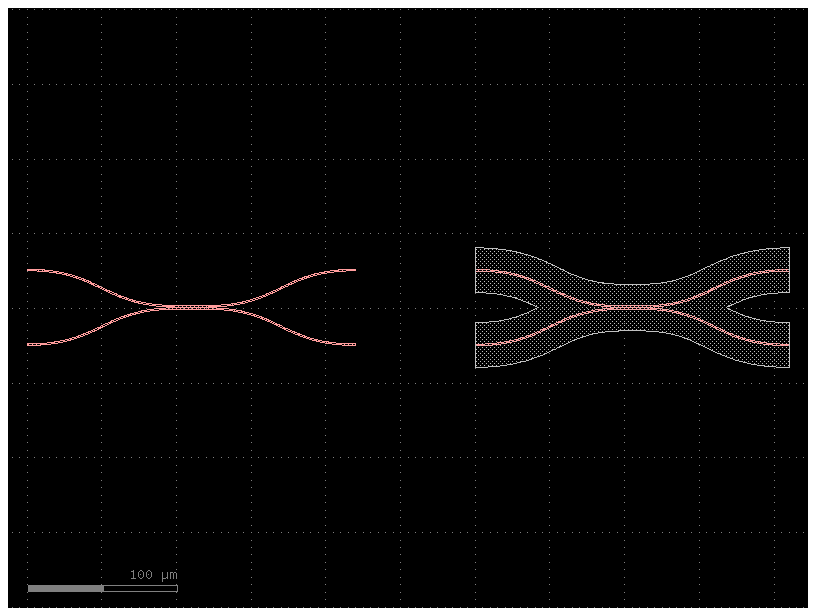

In [87]:
component_DC = gf.Component()

@gf.cell
def DC_cell(length=10.0, gap=0.5, cross_section="strip"):
    c = gf.Component()
    if cross_section=="strip":
        dc = cells.coupler(length=length, gap=gap)
    else:
        dc = cells.coupler_rib(length=length, gap=gap)

    dc_ref = c.add_ref(dc)
    c.add_ports(dc_ref.ports)
    return c


dc2 = component_DC.add_ref(DC_cell(length=20.0, gap=0.5)).dmovex(0).dmovey(0)

dc3 = component_DC.add_ref(DC_cell(length=10.0, gap=0.2, cross_section="rib")).dmovex(300).dmovey(0)

component_DC.plot()
component_DC.show()

### B. Multi-Mode Interferometers (MMI)

2026-06-06 19:50:45.406 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


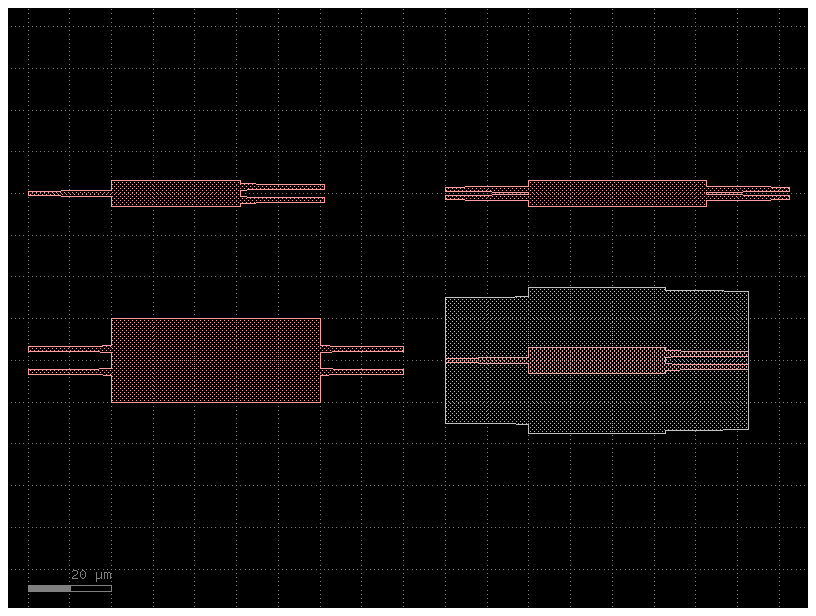

In [88]:
component_library = gf.Component()

mmi_1x2 = cells.mmi1x2()
mmi_1x2_ref = component_library.add_ref(mmi_1x2).dmovex(0).dmovey(0)

mmi_2x2 = cells.mmi2x2()
mmi_2x2_ref = component_library.add_ref(mmi_2x2).dmovex(100).dmovey(0)

mmi_2x2_alt = cells.mmi2x2(width_mmi=20.0, length_mmi=50.0, gap_mmi=4)
mmi_2x2_alt_ref = component_library.add_ref(mmi_2x2_alt).dmovex(0).dmovey(-40)

mmi_1x2_rib = cells.mmi1x2_rib()
mmi_1x2_rib_ref = component_library.add_ref(mmi_1x2_rib).dmovex(100).dmovey(-40)

component_library.plot()
component_library.show()

### C. Mach-Zehnder Interferometers (MZI)

2026-06-06 19:50:56.690 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


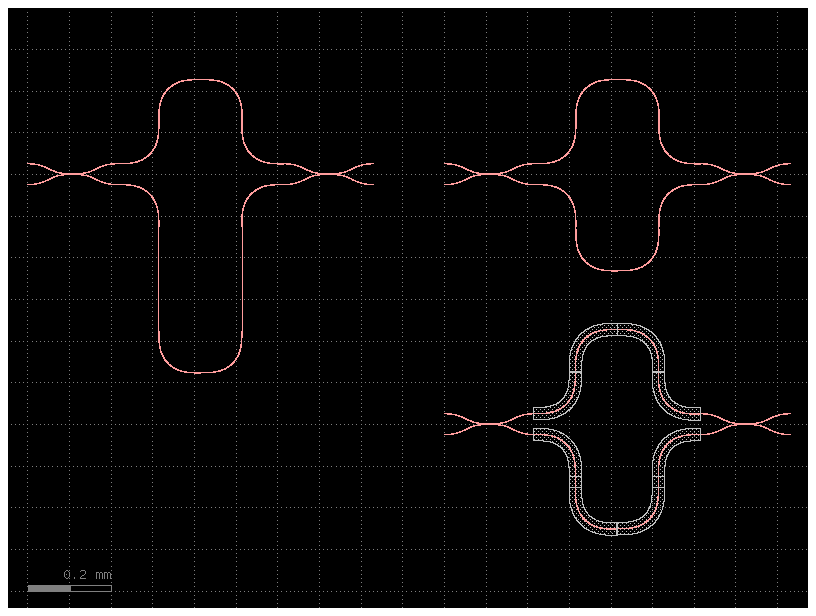

In [90]:
component_MZI = gf.Component()

def agregar_mzi(library, delta_length, x, y, cross_section="strip"):
    mzi_cell = cells.mzi(delta_length=delta_length, cross_section=cross_section)
    mzi_ref = library.add_ref(mzi_cell).dmovex(x).dmovey(y)
    return mzi_ref


agregar_mzi(library=component_MZI, delta_length=500.0, x=0, y=0)
agregar_mzi(library=component_MZI, delta_length=10.0, x=1000, y=0)
agregar_mzi(library=component_MZI, delta_length=50.0, x=1000, y=-600, cross_section="rib")

component_MZI.plot()
component_MZI.show()

### D. Ring Resonators

2026-06-06 19:50:59.735 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


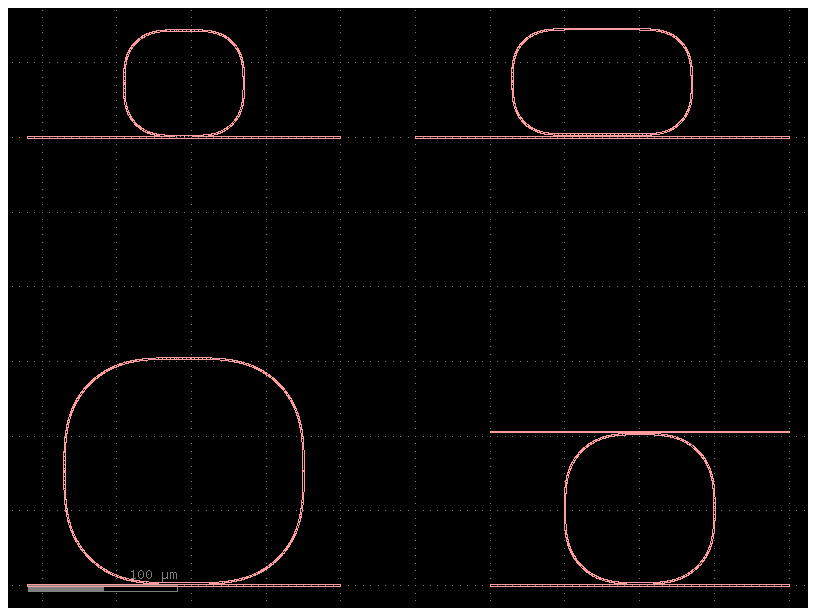

In [91]:
component_RING = gf.Component()

def agregar_ring(library, radius, gap, length_x=0.0, x=0, y=0, tipo="single", gap_top=0.5, gap_bot=0.5, cross_section="strip"):

    if tipo == "single":
        ring_cell = cells.ring_single(radius=radius, gap=gap, length_x=length_x, cross_section=cross_section)
    elif tipo == "double":
        ring_cell = cells.ring_double(radius=radius, gap=gap, gap_top=gap_top, gap_bot=gap_bot, length_x=length_x, cross_section=cross_section)
    else:
        raise ValueError("El tipo de anillo debe ser 'single' o 'double'")
    
    ring_ref = library.add_ref(ring_cell).dmovex(x).dmovey(y)
    return ring_ref

agregar_ring(component_RING, radius=35.0, gap=0.0, length_x=10.0, x=0, y=0)
agregar_ring(component_RING, radius=35.0, gap=1.0, length_x=50.0, x=300, y=0)
agregar_ring(component_RING, radius=75.0, gap=0.5, length_x=10.0, x=0, y=-300)
agregar_ring(component_RING, radius=50.0, gap=0.5, x=300, y=-300, tipo="double", gap_top=0.5, gap_bot=0.5)

component_RING.plot()
component_RING.show()

## 2. Layout Fundamentals

A cell is a function that returns a Component. In GDS each component must have a unique name. Two components stored in the GDS file cannot have the same name. They need to be references (instances) of the same component.

![GDSFactoryComponents][def]


[def]: https://i.imgur.com/oeuKGsc.png

2026-06-06 16:45:28.801 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


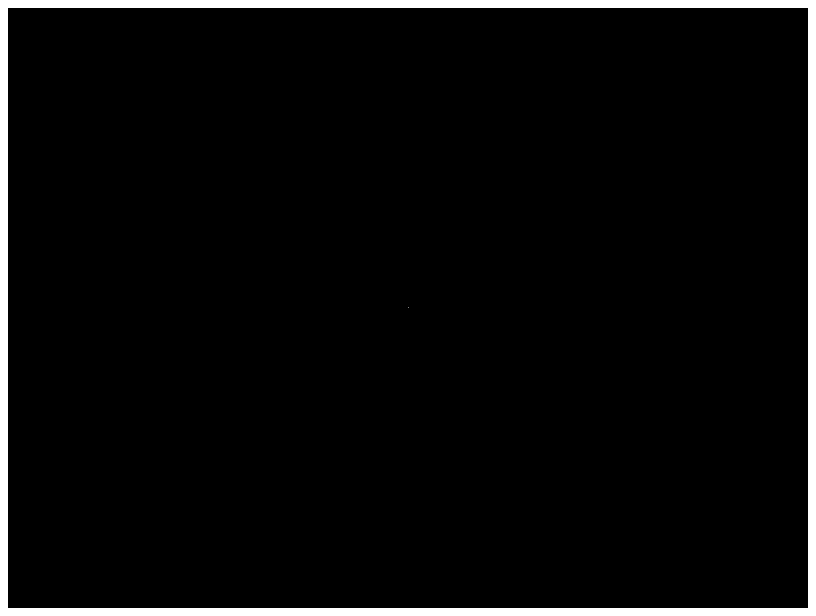

In [12]:
c = gf.Component()
c.plot()
c.show()

Let's build a Component from scratch. A die (chip) for a photonic layout. The PDK or Design Manual should specify the Layer for the bounding box (dicing line). 
We should also consider: 
1. The die dimensions and 
2. The border for dicing 

2026-06-06 16:45:28.919 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


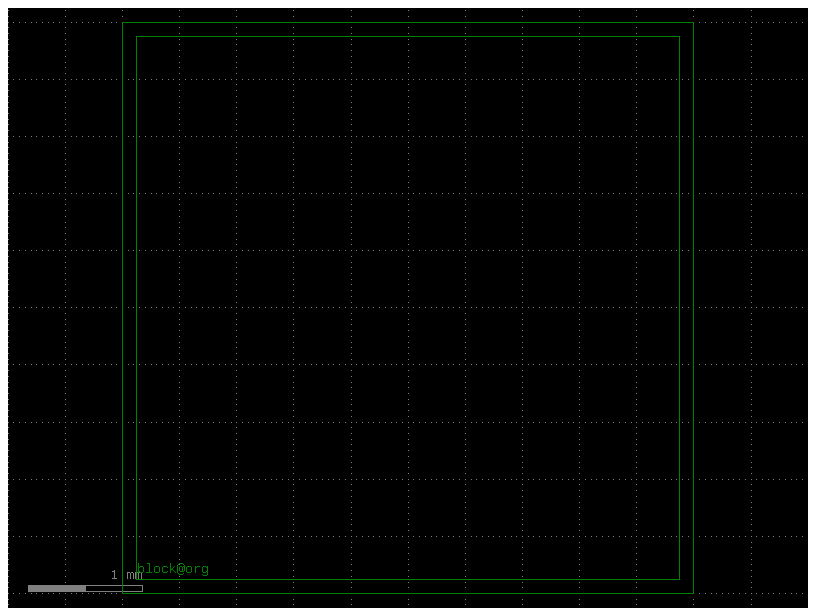

In [13]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

box.draw_ports()
box.show()
box.plot()

### Mantra: 
Once that we have a working 'new' component, we shall convert it into a Cell. This will allow us to have a hierarchical design

2026-06-06 16:45:29.093 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


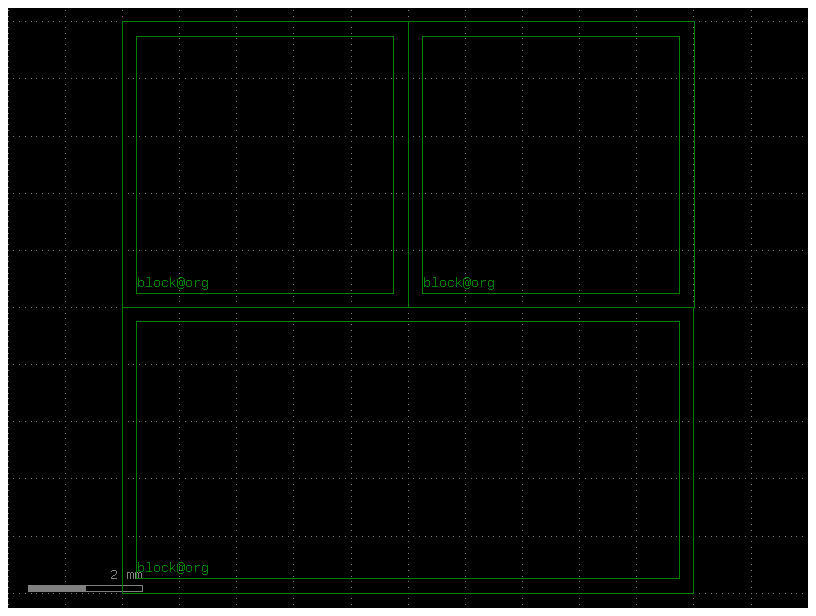

In [14]:
# 1. We define the cell as a function with it's corresponding parameters (and defaults)
gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
wafer = gf.Component()
dieW1 = 5000
dieW2 = 10000

c1 = wafer.add_ref(die(dieW = dieW))
c2 = wafer.add_ref(die(dieW = dieW))
c3 = wafer.add_ref(die(dieW = 10000))

c2.dmovex(dieW1)
c3.dmovey(-5000)
wafer.show()
wafer.plot()


- - Use your design results from Lab2 and Lab3 to create layout instances of your designed components: DCs, MMIs, MZIs & Ring Resonators”  Make cells for all your components. 

### A. Directional Couplers (DC)

2026-06-06 16:45:29.239 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


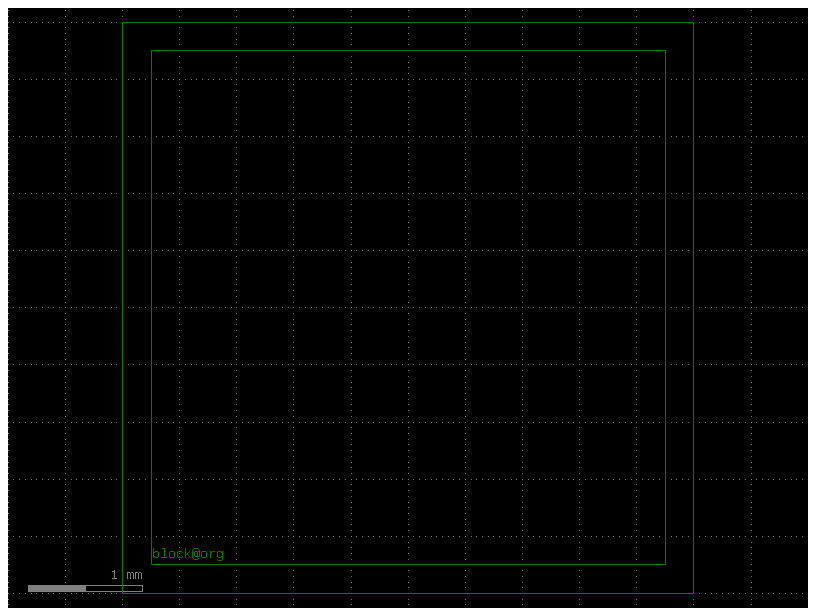

In [15]:
gf.clear_cache()
wafer_coupler = gf.Component()
dieW1 = 5000
dieW2 = 10000

cell_coupler = wafer_coupler.add_ref(die(dieW = dieW))
wafer_coupler.show()
wafer_coupler.plot()

### B. Multi-Mode Interferometers (MMI)

2026-06-06 16:45:29.371 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


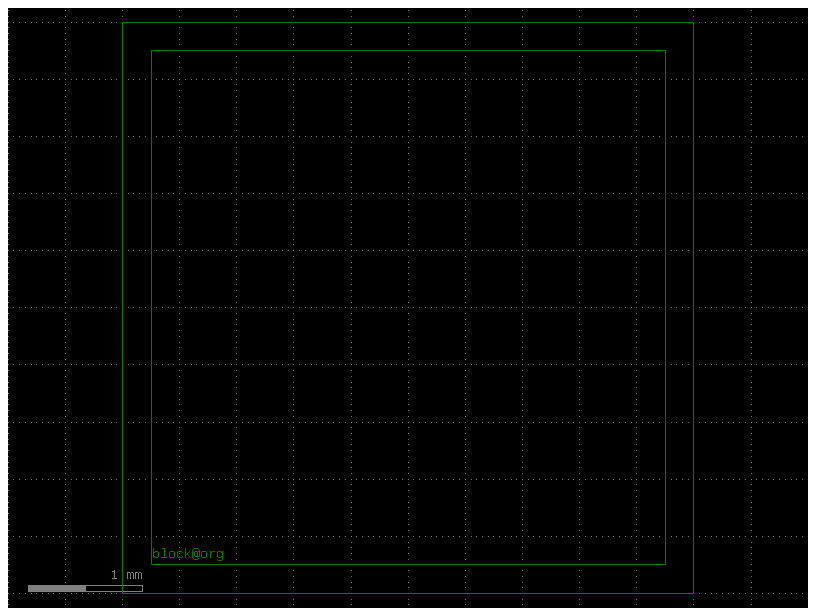

In [16]:
wafer_MMI = gf.Component()
dieW1 = 5000
dieW2 = 10000

cell_MMI = wafer_MMI.add_ref(die(dieW = dieW))
wafer_MMI.show()
wafer_MMI.plot()

### C. Mach-Zehnder Interferometers (MZI)

2026-06-06 16:45:29.508 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


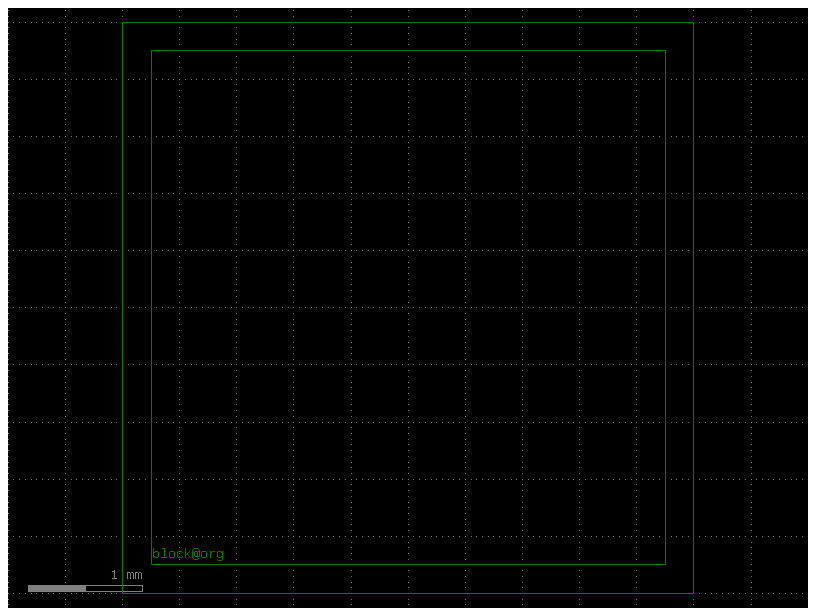

In [17]:
wafer_MZI = gf.Component()
dieW1 = 5000
dieW2 = 10000

cell_MZI = wafer_MZI.add_ref(die(dieW = dieW))
wafer_MZI.show()
wafer_MZI.plot()

### D. Ring Resonators

2026-06-06 16:45:29.637 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


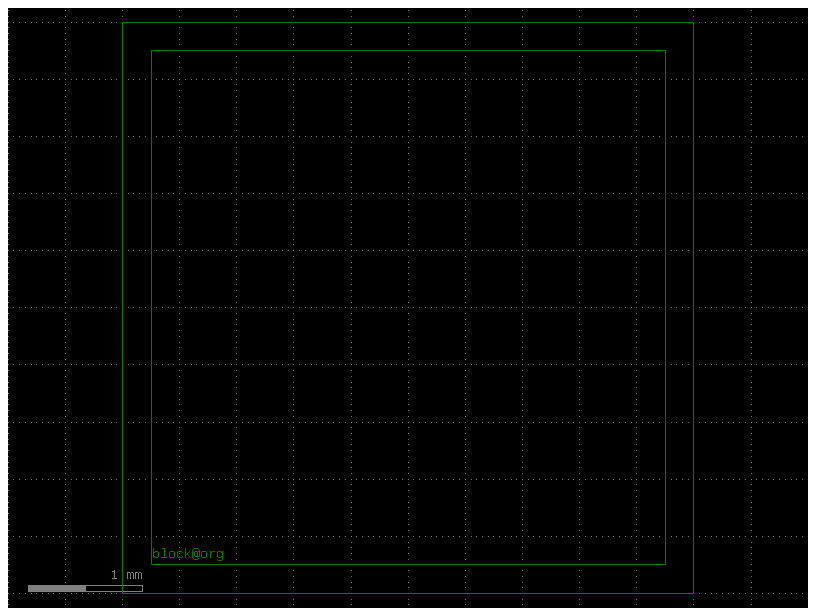

In [18]:
wafer_RING = gf.Component()
dieW1 = 5000
dieW2 = 10000

cell_RING = wafer_RING.add_ref(die(dieW = dieW))
wafer_RING.show()
wafer_RING.plot()

## 3. Complete Layout

2026-06-06 16:45:29.860 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


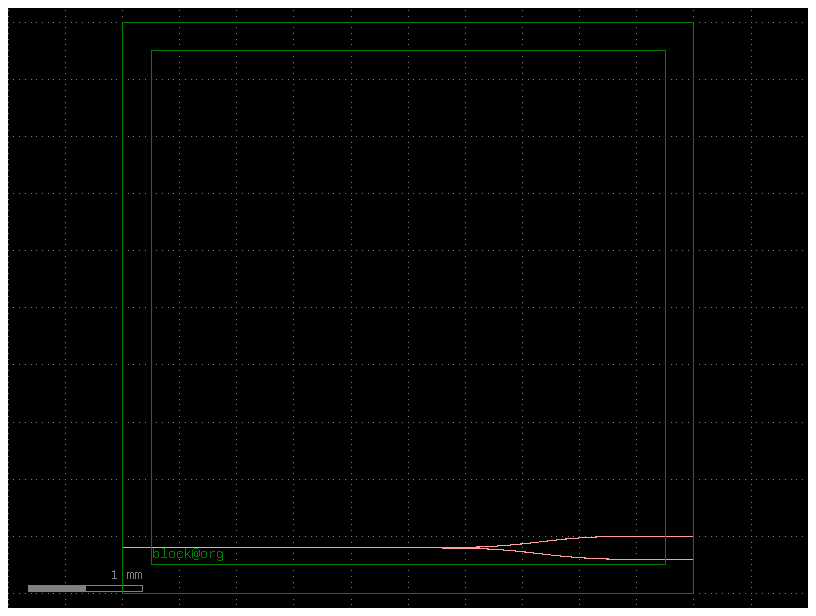

In [19]:
layer_wg  = "WG"
minrad = 50
dieW = 5000

main = gf.Component()

die_ref = main.add_ref(die(dieW = dieW, layer_box="FLOORPLAN"))

## Add first a test MMI routed from side to side
c_mmi = cells.mmi1x2()
mmi = main.add_ref(c_mmi)
mmi.dmovex(die_ref["block@org"].dx + 0.5*dieW).dmovey(die_ref['block@org'].dy + 150)

## Route waveguides from MMI to the die edges
xs = 'strip'
### First add the i/o waveguides - to be sure you 'cut' on a straight section
strin = (main.add_ref(gf.components.straight(length=500, cross_section='strip')).dmovex(0).dmovey(mmi['o1'].dy))
strout1 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o3'].dy-100).dmovex(dieW))
strout2 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o2'].dy+100).dmovex(dieW))

### Then route from the i/o waveguides to the MMI
gf.routing.route_single_sbend(main,port1=strin['o2'], port2=mmi['o1'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o2'], port2=strout2['o2'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o3'], port2=strout1['o2'], cross_section=xs)

main.plot()
main.show()

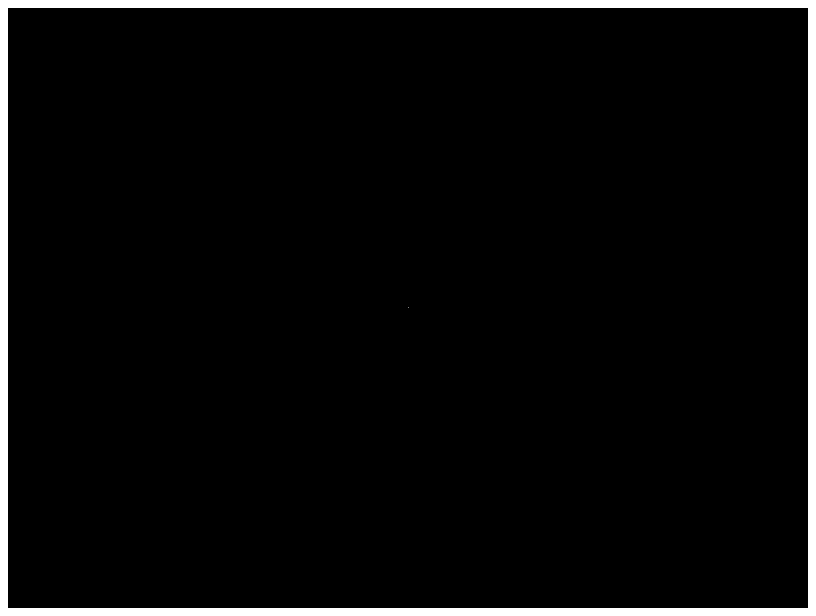

In [20]:
# Let's create a MMI tree

c = gf.Component()
c_mmi = cells.mmi1x2()
...
c.plot()

In [21]:
# Obtiene el PDK que está cargado actualmente en memoria
pdk = gf.get_active_pdk()

# Imprime los nombres de todas las secciones transversales registradas
print(list(pdk.cross_sections.keys()))
#help(cells.ring_single)
#help(cells.spiral_racetrack_fixed_length)
# Reemplaza 'cells' por el nombre exacto de tu módulo de celdas si es diferente
print(dir(cells))

['cross_section', 'heater_metal', 'metal_routing', 'rib', 'strip', 'strip_heater_metal']
['Any', 'ComponentSpec', 'CrossSectionSpec', 'Floats', 'Ints', 'LAYER', 'LayerSpec', 'LayerSpecs', 'PATH', 'Size', 'TECH', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'bend_euler', 'bend_metal', 'bend_s', 'bend_s_metal', 'compass', 'containers', 'coupler', 'coupler_rib', 'coupler_ring', 'couplers', 'crossing', 'die', 'die_with_pads', 'fixed', 'gf', 'grating_coupler_rectangular', 'grating_couplers', 'heaters', 'mmi1x2', 'mmi1x2_rib', 'mmi2x2', 'mmi2x2_rib', 'mmis', 'mzi', 'mzis', 'pad', 'partial', 'port_names_electrical', 'port_types_electrical', 'rectangle', 'ring_double', 'ring_single', 'rings', 'spiral', 'spiral_racetrack_heater', 'spirals', 'straight', 'straight_heater_metal', 'straight_metal', 'straight_rib', 'straight_strip', 'taper', 'taper_metal', 'taper_strip_to_ridge', 'tapers', 'text', 'text_rectangular', 'text_rect

In [22]:
# Once we "test" the high-level component, we can create a cell for it
@gf.cell 
def mmi_tree_1x4(pad_x = 250 ,pad_y = 250):
    c = gf.Component()
    c_mmi = cells.mmi1x2()
    mmi1 = c.add_ref(c_mmi)
    mmi2 = c.add_ref(c_mmi)
    mmi3 = c.add_ref(c_mmi)

    mmi2.dmovex(pad_x).dmovey(pad_y)
    mmi3.dmovex(pad_x).dmovey(-pad_y)

    gf.routing.route_single_sbend(component=c, port1= mmi1['o2'], port2=mmi2['o1'],cross_section='strip')
    gf.routing.route_single_sbend(component=c, port1= mmi1['o3'], port2=mmi3['o1'],cross_section='strip')
    c.add_port(name='o1', port=mmi1['o1'])
    c.add_port(name='o2', port=mmi2['o2'])
    c.add_port(name='o3', port=mmi2['o3'])
    c.add_port(name='o4', port=mmi3['o2'])
    c.add_port(name='o5', port=mmi3['o3'])
    c.draw_ports()
    return c

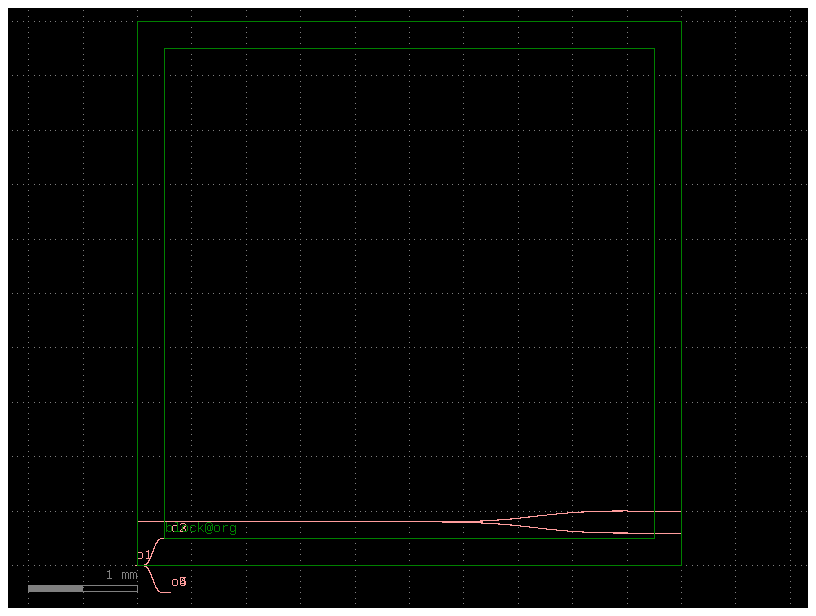

In [23]:
# With the cell created, we can instantiate and use it in our main component

cell_1x4 = main.add_ref(mmi_tree_1x4())
main.plot()


2026-06-06 16:45:30.315 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


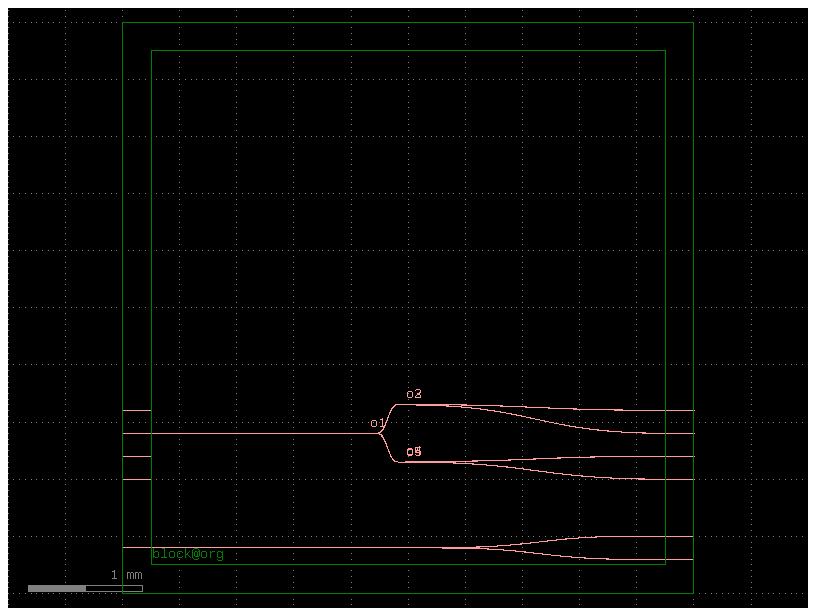

In [24]:
## Arrayed waveguides and MMI tree

sp = 200
border = 250

in_arr = main.add_ref(
    gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
).dmovey(
    1000
)  #!!!!!! Easy to put IO Waveguides for a complete design !!!!

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(1000)
)

cell_1x4.dmovex(0.5*dieW - mmi_tree_1x4().dxsize).dmovey(in_arr['o6'].dy)
gf.routing.route_single_sbend(component=main, port1=in_arr['o6'], port2=cell_1x4['o1'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o2'], port2=out_arr['o4'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o3'], port2=out_arr['o3'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o4'], port2=out_arr['o2'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o5'], port2=out_arr['o1'])
main.plot()
main.show()

2026-06-06 19:51:38.833 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


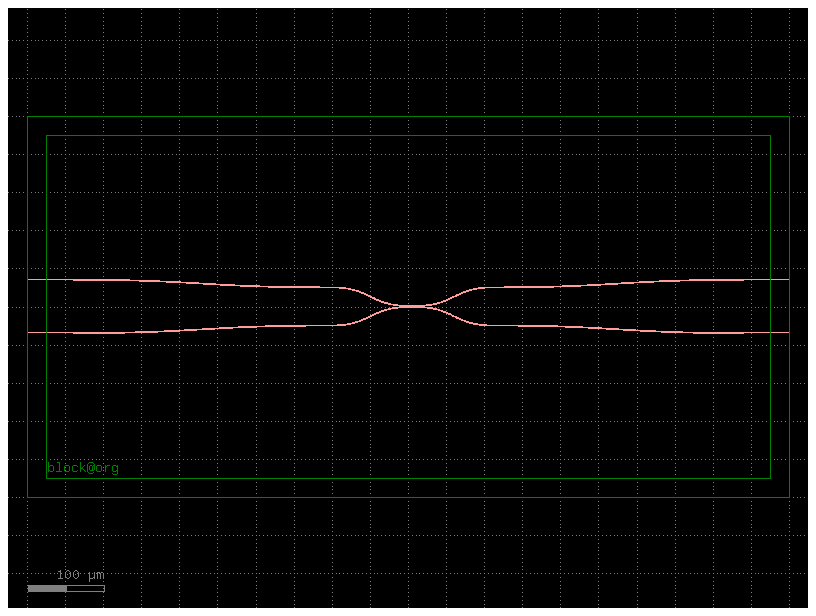

In [93]:
DC_wafer = gf.Component()

dieW = 1000; dieL = 500; border = 25; xs="strip"

die_ref = DC_wafer.add_ref(die(dieW=dieW, dieL=dieL, border=border, layer_box="FLOORPLAN"))

dc_short_ref = DC_wafer.add_ref(DC_cell(length=10.0, gap=0.5)).dmovex(500).dmovey(250)

# ========================================================
# PASO 4: Rutado desde el Acoplador hacia los bordes del chip
# ========================================================

strin1 = DC_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).dmovex(0).dmovey(dc_short_ref['o1'].dy + 60)
strin2 = DC_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).dmovex(0).dmovey(dc_short_ref['o2'].dy - 60)

strout1 = DC_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).drotate(180).dmovex(dieW).dmovey(dc_short_ref['o4'].dy + 60)
strout2 = DC_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).drotate(180).dmovex(dieW).dmovey(dc_short_ref['o3'].dy - 60)

# Conexiones de Entrada (Lado Izquierdo)
gf.routing.route_single_sbend(DC_wafer, port1=strin1['o2'], port2=dc_short_ref['o2'], cross_section='strip')
gf.routing.route_single_sbend(DC_wafer, port1=strin2['o2'], port2=dc_short_ref['o1'], cross_section='strip')

# Conexiones de Salida (Lado Derecho)
gf.routing.route_single_sbend(DC_wafer, port1=dc_short_ref['o3'], port2=strout1['o2'], cross_section='strip')
gf.routing.route_single_sbend(DC_wafer, port1=dc_short_ref['o4'], port2=strout2['o2'], cross_section='strip')

# ========================================================
# PASO 5: Visualización
# ========================================================
DC_wafer.plot()
DC_wafer.show()

### Mantra:
It's useful to use memorize this mantra: 
- Add_references 
- Connect_them
- Move_them

### Other Routing options examples:

Please check the GDSFactory Routing API for more information about advanced routing functionalities

[Routing API](https://gdsfactory.github.io/gdsfactory/api_routing.html) 

## 4. Exercises. 

Part a) Creating components
- Create a cell component for a unbalanced MZI, using 2x2 50:50 MMIs with arm length difference as parameter

2026-06-06 16:45:30.707 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


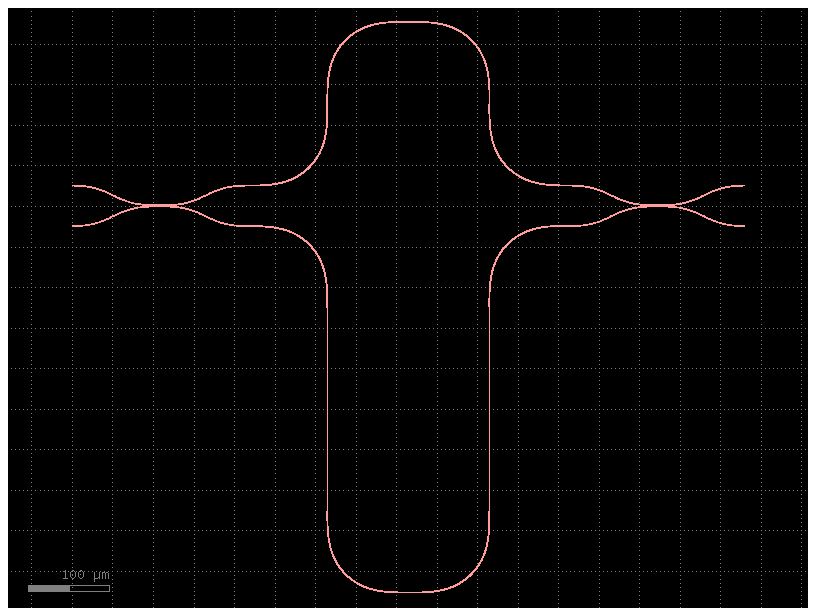

In [26]:
a1 = gf.Component("Mi componente a1")
agregar_mzi(library=a1, delta_length=500.0, x=0, y=0, cross_section="strip")

a1.plot()
a1.show()

- Create a cell component based on the previous, where the arms have thermal tuners on top of each one

2026-06-06 16:45:30.901 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


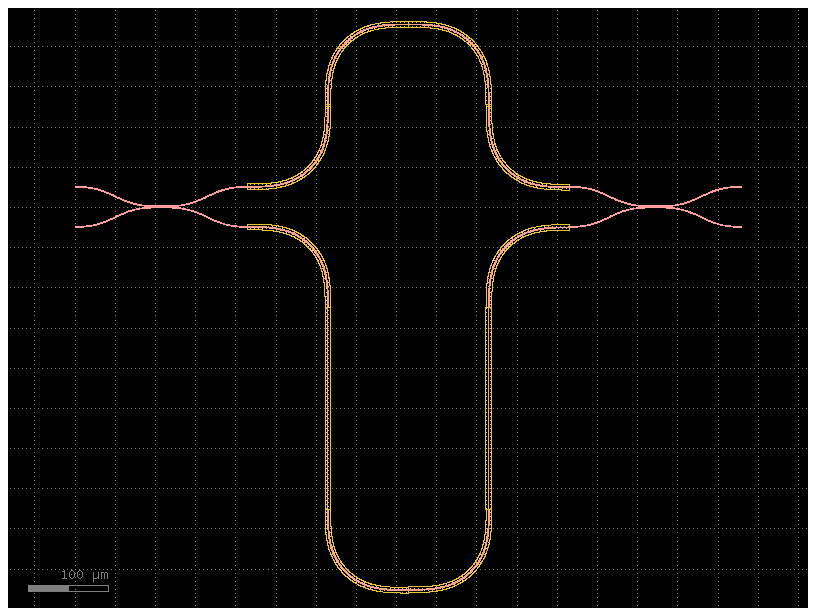

In [27]:
a2 = gf.Component("Mi componente a2")
agregar_mzi(library=a2, delta_length=500.0, x=0, y=0, cross_section="strip_heater_metal")

a2.plot()
a2.show()

- Create a cell component for an all-pass ring resonator, using 2x2 50:50 MMIs, with extra length parameter for different perimeters

2026-06-06 16:45:31.129 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


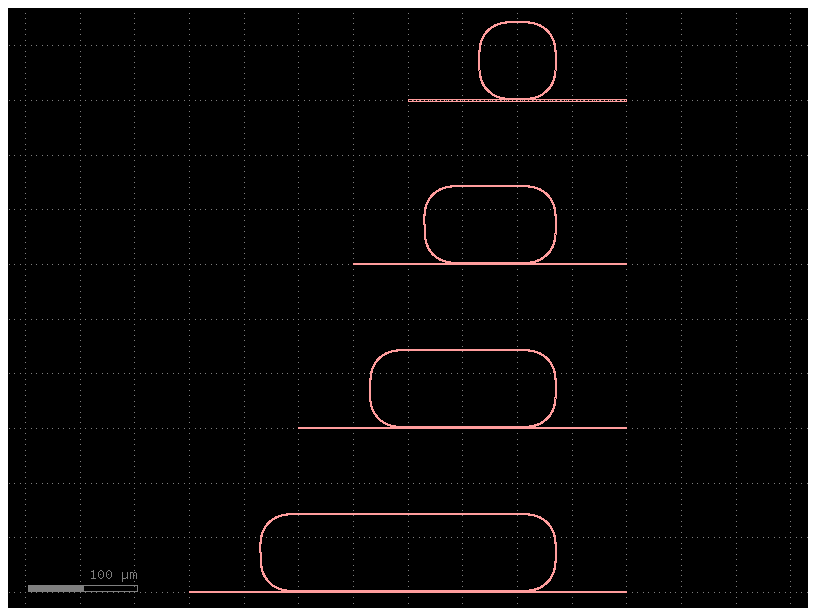

In [28]:
gf.clear_cache()
a3 = gf.Component("Mi componente a3")

agregar_ring(library=a3, radius=35.0, gap=0.2, length_x=0.0, x=0, y=0, tipo="single")
agregar_ring(library=a3, radius=35.0, gap=0.2, length_x=50.0, x=0, y=-150, tipo="single")
agregar_ring(library=a3, radius=35.0, gap=0.2, length_x=100.0, x=0, y=-300, tipo="single")
agregar_ring(library=a3, radius=35.0, gap=0.2, length_x=200.0, x=0, y=-450, tipo="single")

a3.plot()
a3.show()

- Create a cell component based on the previous, where the ring has a thermal tuner on top along all the perimeter

2026-06-06 16:54:34.432 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


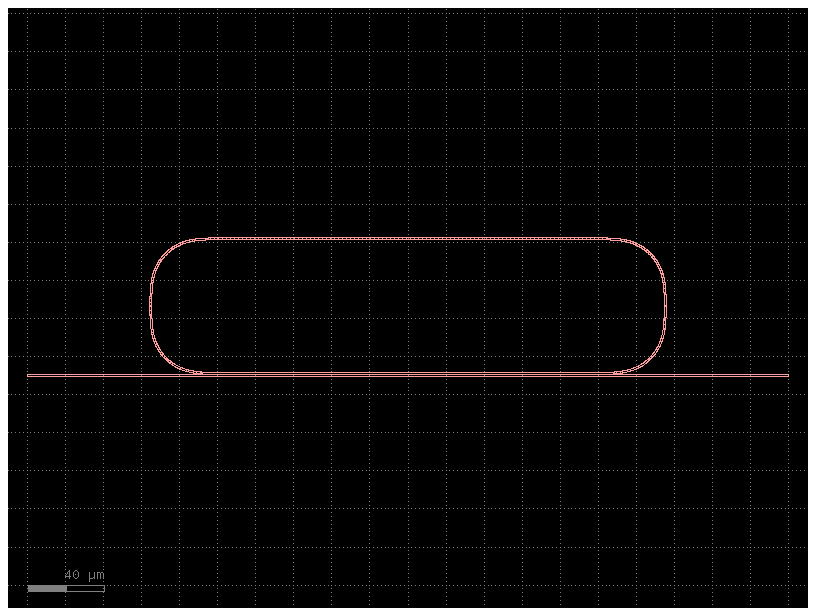

In [34]:
gf.clear_cache()
a4 = gf.Component("Mi componente a4")
def agregar_ring(library, radius, gap, length_x=0.0, x=0, y=0, tipo="single", gap_top=0.5, gap_bot=0.5, cross_section="strip"):

    if tipo == "single":
        ring_cell = cells.ring_single(radius=radius, gap=gap, length_x=length_x, cross_section=cross_section)
    elif tipo == "double":
        ring_cell = cells.ring_double(radius=radius, gap=gap, gap_top=gap_top, gap_bot=gap_bot, length_x=length_x, cross_section=cross_section)
    else:
        raise ValueError("El tipo de anillo debe ser 'single' o 'double'")
    
    ring_ref = library.add_ref(ring_cell).dmovex(x).dmovey(y)
    return ring_ref

agregar_ring(library=a4, radius=35.0, gap=0.2, length_x=200.0, x=0, y=-450, tipo="single", cross_section="strip")

a4.plot()
a4.show()

2026-06-05 17:32:54.219 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


/home/jfgimloz/CIFOIN_PRACTICA_4/cifoin-lab4/.venv/lib/python3.12/site-packages/gdsfactory/components/couplers/coupler90.py:44: UserWarning: {'radius': 35.0} ignored for cross_section 'xs_7914a7e7'
  x = gf.get_cross_section(cross_section, radius=radius)


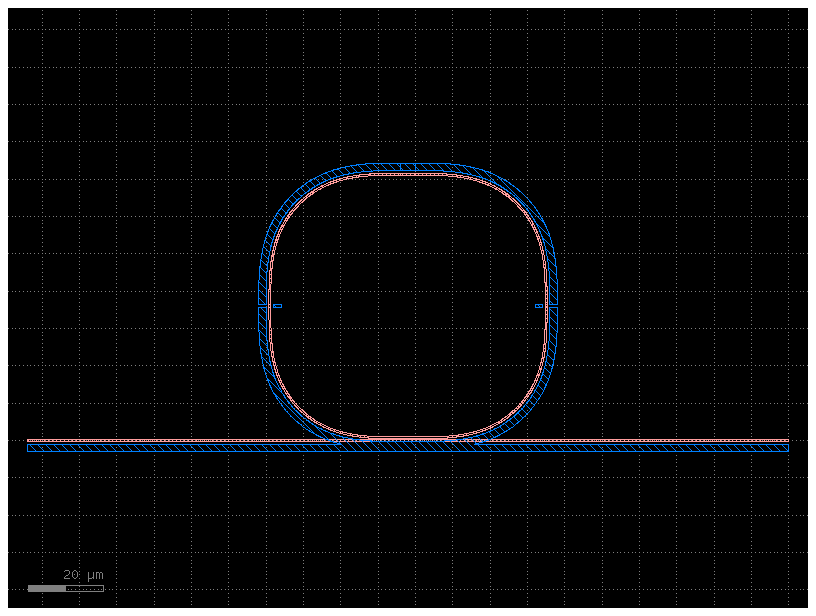

In [ ]:
gf.clear_cache()

@gf.cell
def ring_with_heater(radius=35.0, gap=0.2):

    # Cross-section con heater integrado
    xs = gf.cross_section.cross_section(
        width=0.5,             # waveguide
        layer=(1, 0),
        sections=[
            gf.cross_section.Section(
                width=2.0,
                offset=2.0,   # altura respecto al core
                layer=(47, 0) # metal
            )
        ]
    )

    c = gf.components.ring_single(
        radius=radius,
        gap=gap,
        cross_section=xs
    )

    return c


a4 = ring_with_heater()
a4.plot()
a4.show()

- Create a cell component based on existing GDSfactory spiral components, with length as parameter

2026-06-06 16:56:36.298 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


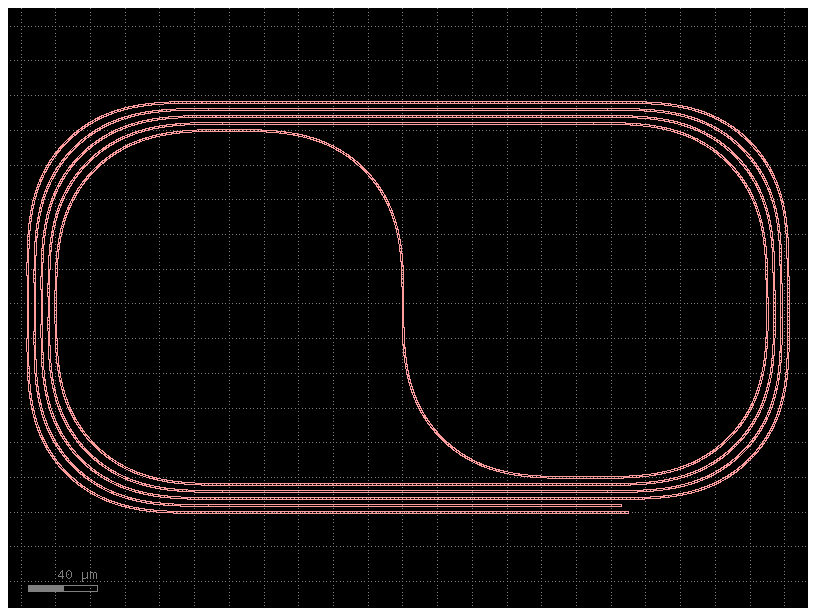

In [36]:
gf.clear_cache()

def agregar_spiral(library, length, x, y, n_loops=1, spacing=4.0, cross_section="strip"):

    spiral_cell = gf.components.spiral(length=length, n_loops=n_loops, spacing=spacing, cross_section=cross_section)
    spiral_ref = library.add_ref(spiral_cell).dmovex(x).dmovey(y)
    return spiral_ref
#'spiral', 'spiral_racetrack_heater', 'spirals
a5 = gf.Component("Mi componente a5")

agregar_spiral(library=a5, length=10.0, x=0, y=0, n_loops=5, cross_section="strip")

a5.plot()
a5.show()

Part b) Creating die
- Create a die  W = 5 mm x L = 10 mm 

2026-06-05 17:54:34.901 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


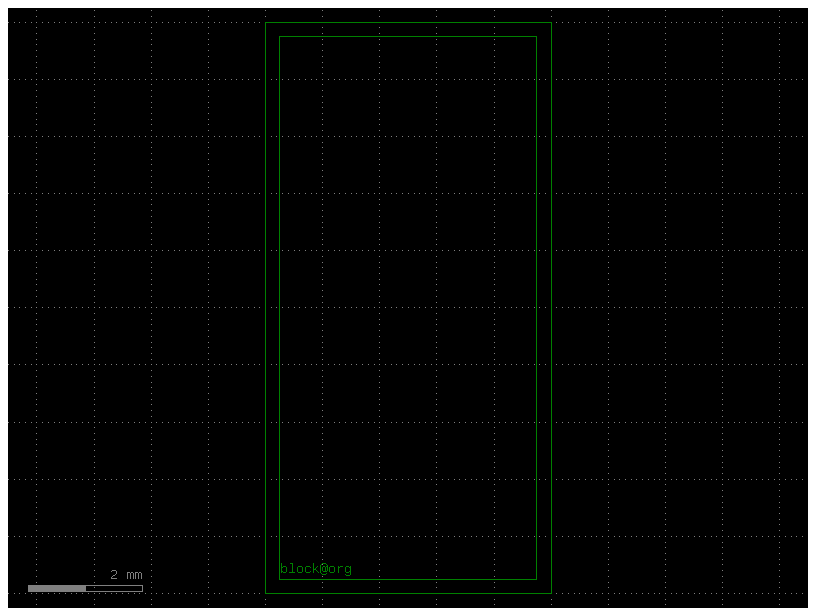

In [ ]:
new_die = gf.Component()
die = new_die.add_ref(die(dieW = 5000, dieL=10000))
new_die.show()
new_die.plot()

- Create an array of I/Os spaced at 250 µm (as much I/Os as the width allows)

2026-06-05 18:05:11.721 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


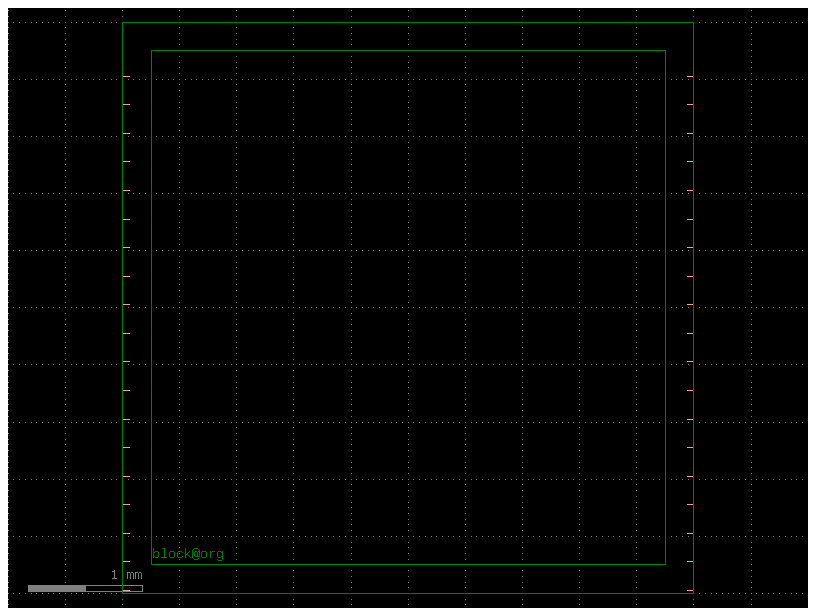

In [ ]:
gf.clear_cache()
die_ios_only = gf.Component()

die_cell = die_ios_only.add_ref(die(dieW = 5000, dieL=5000))

# ========================================================
# PASO 2: Generar y posicionar la matriz de I/Os
# ========================================================
spacing = 250.0
io_length = 60.0
ancho_util = dieW - (2 * border)  # 4500 µm de zona útil

# Calculamos cuántas guías caben
num_ios = int(ancho_util // spacing) + 1

# Generamos la matriz automática en los límites verticales izquierdo y derecho
for i in range(num_ios):
    y_pos = 25 + (i * spacing)
    
    # ENTRADAS (Borde Izquierdo)
    strin = die_ios_only.add_ref(gf.components.straight(length=io_length, cross_section=xs))
    strin.dmovex(0).dmovey(y_pos)
    
    # SALIDAS (Borde Derecho)
    strout = die_ios_only.add_ref(gf.components.straight(length=io_length, cross_section=xs))
    strout.drotate(180).dmovex(dieW).dmovey(y_pos)


die_ios_only.show()
die_ios_only.plot()

- Create a cell component of this die, with I/Os accessible to connect

2026-06-06 19:45:24.421 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


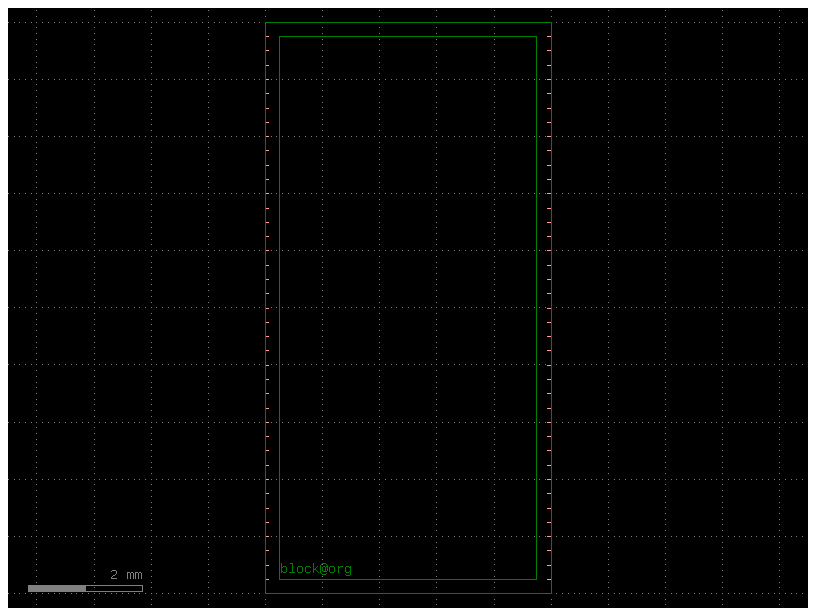

In [75]:
gf.clear_cache()
die_ios_only = gf.Component()

spacing = 250.0
io_length = 60.0
border = 250  
dieW = 5000
dieL = 10000

die_cell = die_ios_only.add_ref(die(dieW = dieW, dieL=dieL))


ancho_util = dieL - (2 * border)  # 4500 µm de zona útil
num_ios = int(ancho_util // spacing) + 1

for i in range(num_ios):
    y_pos = border + (i * spacing)  # Empezamos en el borde útil real (250)
    
    strin = die_ios_only.add_ref(gf.components.straight(length=io_length, cross_section="strip"))
    strin.dmovex(0).dmovey(y_pos)
    
    die_ios_only.add_port(name=f"IO_IN_{i}", port=strin.ports["o2"])
    
    strout = die_ios_only.add_ref(gf.components.straight(length=io_length, cross_section="strip"))
    strout.drotate(180).dmovex(dieW).dmovey(y_pos)
    
    die_ios_only.add_port(name=f"IO_OUT_{i}", port=strout.ports["o2"])


#die_ios_only.draw_ports()
die_ios_only.show()
die_ios_only.plot()

Part c) Floorplaning and die layout
- Make an instance of the die as host component for your layout

In [49]:
gf.clear_cache()
layout_final = gf.Component("Mi_Layout_Principal")
die_instancia = layout_final.add_ref(die())

- Add 3 sets of 3 straight waveguides, from left to right of the die, top, middle and bottom of the die

2026-06-06 17:07:23.920 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


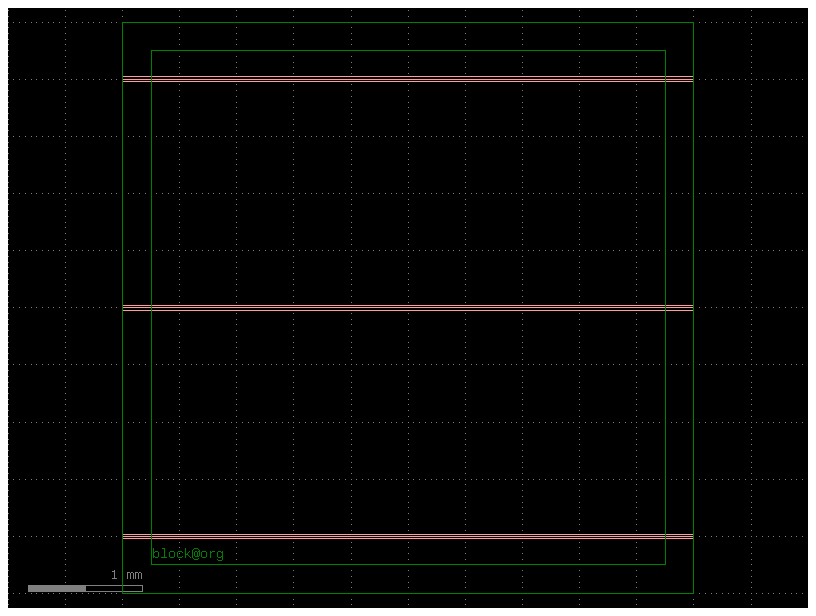

In [50]:
largo_guia = 5000.0  
xs = 'strip'

alturas_grupos = {
    "top": 4500.0,
    "middle": 2500.0,
    "bottom": 500.0
}

separacion_interna = 20.0

for zona, y_centro in alturas_grupos.items():
    for i in range(3):
      
        y_pos = y_centro + ((i - 1) * separacion_interna)
        
        guia_recta = layout_final.add_ref(gf.components.straight(length=largo_guia, cross_section=xs))
        
        guia_recta.dmovex(0).dmovey(y_pos)

layout_final.show()
layout_final.plot()

- Add 2 of each of the components above, with different lengths

- Connect all your components to the I/Os 

2026-06-06 20:07:46.706 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


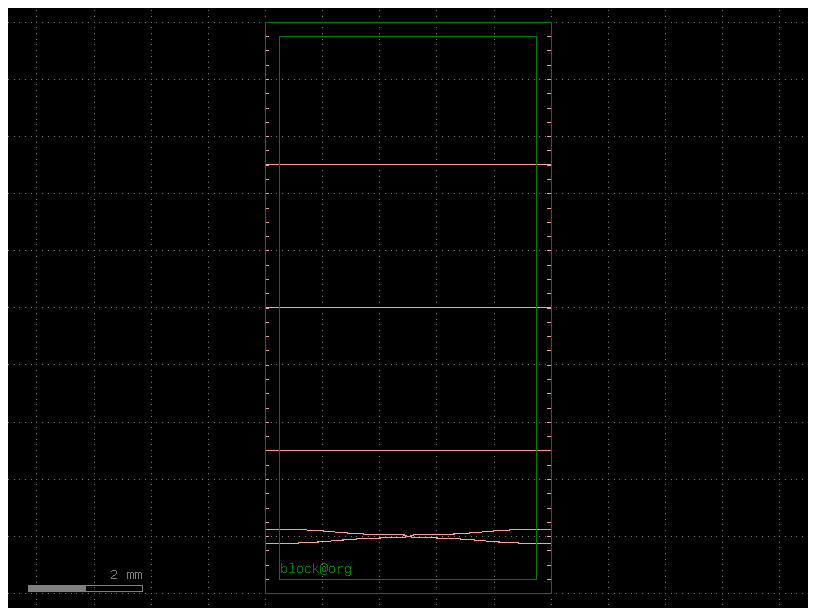

In [124]:
layout_final = gf.Component()

dieW = 5000; dieL = 5000  ; border = 250; xs = 'strip'; spacing = 250.0; io_length = 60.0

die_instancia = layout_final.add_ref(die_ios_only)

# Se cambia la posición Y de 250 a 500 para centrar la celda verticalmente
die_cell_ref = layout_final.add_ref(DC_cell()).dmovex(2500).dmovey(1000)


# Se ajustan las guías rectas de referencia para reflejar el cambio de posición
guia_recta_low = layout_final.add_ref(gf.components.straight(length=dieW, cross_section=xs)).dmovex(0).dmovey(2500)
guia_recta_middle = layout_final.add_ref(gf.components.straight(length=dieW, cross_section=xs)).dmovex(0).dmovey(5000)
guia_recta_top = layout_final.add_ref(gf.components.straight(length=dieW, cross_section=xs)).dmovex(0).dmovey(7500)




strin1 = layout_final.add_ref(gf.components.straight(length=60, cross_section=xs)).dmovex(0).dmovey(die_cell_ref.ports['o2'].dy + 100)
strin2 = layout_final.add_ref(gf.components.straight(length=60, cross_section=xs)).dmovex(0).dmovey(die_cell_ref.ports['o1'].dy - 100)

strout1 = layout_final.add_ref(gf.components.straight(length=60, cross_section=xs)).drotate(180).dmovex(dieW).dmovey(die_cell_ref.ports['o3'].dy + 100)
strout2 = layout_final.add_ref(gf.components.straight(length=60, cross_section=xs)).drotate(180).dmovex(dieW).dmovey(die_cell_ref.ports['o4'].dy - 100)

# Conexiones de Entrada (Lado Izquierdo)
gf.routing.route_single_sbend(layout_final, port1=strin1.ports['o2'], port2=die_cell_ref.ports['o2'], cross_section='strip')
gf.routing.route_single_sbend(layout_final, port1=strin2.ports['o2'], port2=die_cell_ref.ports['o1'], cross_section='strip')

# Conexiones de Salida (Lado Derecho)
gf.routing.route_single_sbend(layout_final, port1=die_cell_ref.ports['o3'], port2=strout1.ports['o2'], cross_section='strip')
gf.routing.route_single_sbend(layout_final, port1=die_cell_ref.ports['o4'], port2=strout2.ports['o2'], cross_section='strip')

# ========================================================
# PASO 6: Visualización final
# ========================================================
layout_final.plot()
layout_final.show()

In [ ]:
# Obtiene el PDK que está cargado actualmente en memoria
pdk = gf.get_active_pdk()

# Imprime los nombres de todas las secciones transversales registradas
print(list(pdk.cross_sections.keys()))
#help(cells.ring_single)
#help(cells.spiral_racetrack_fixed_length)
# Reemplaza 'cells' por el nombre exacto de tu módulo de celdas si es diferente
print(dir(cells))
#help(cells.spiral)

['cross_section', 'heater_metal', 'metal_routing', 'rib', 'strip', 'strip_heater_metal']
['Any', 'ComponentSpec', 'CrossSectionSpec', 'Floats', 'Ints', 'LAYER', 'LayerSpec', 'LayerSpecs', 'PATH', 'Size', 'TECH', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'bend_euler', 'bend_metal', 'bend_s', 'bend_s_metal', 'compass', 'containers', 'coupler', 'coupler_rib', 'coupler_ring', 'couplers', 'crossing', 'die', 'die_with_pads', 'fixed', 'gf', 'grating_coupler_rectangular', 'grating_couplers', 'heaters', 'mmi1x2', 'mmi1x2_rib', 'mmi2x2', 'mmi2x2_rib', 'mmis', 'mzi', 'mzis', 'pad', 'partial', 'port_names_electrical', 'port_types_electrical', 'rectangle', 'ring_double', 'ring_single', 'rings', 'spiral', 'spiral_racetrack_heater', 'spirals', 'straight', 'straight_heater_metal', 'straight_metal', 'straight_rib', 'straight_strip', 'taper', 'taper_metal', 'taper_strip_to_ridge', 'tapers', 'text', 'text_rectangular', 'text_rect